# EDA TELCO CHURN
## FUENTE : https://www.kaggle.com/datasets/hrishikeshjadhav/telco-customer-churn-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%run '/content/pandas_missing_extension.ipynb'

In [3]:
data_df = pd.read_csv('/content/Telco-Customer-Churn.csv')
data_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [4]:
data_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
import re

def to_snake_case(name):
    # Insert an underscore before any uppercase letter that is not at the start of the string
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
    return name.lower()

data_df.columns = [to_snake_case(col) for col in data_df.columns]

In [6]:
data_df

,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# TRATAMIENTO DE DATOS FALTANTES

In [10]:
data_df.missing.number_missing()

np.int64(0)

## GENERMAOS DATOS FALTANTES

In [13]:
data_df['multiple_lines'] = data_df['multiple_lines'].replace('No phone service', np.nan)

In [15]:
data_df.loc[data_df['tenure'] > 70, 'tenure'] = np.nan

In [16]:
data_df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,customer_i_d,0,7032,0.000000
1,gender,0,7032,0.000000
2,senior_citizen,0,7032,0.000000
3,partner,0,7032,0.000000
4,dependents,0,7032,0.000000
5,tenure,532,7032,7.565415
6,phone_service,0,7032,0.000000
7,multiple_lines,680,7032,9.670080
8,internet_service,0,7032,0.000000
9,online_security,0,7032,0.000000


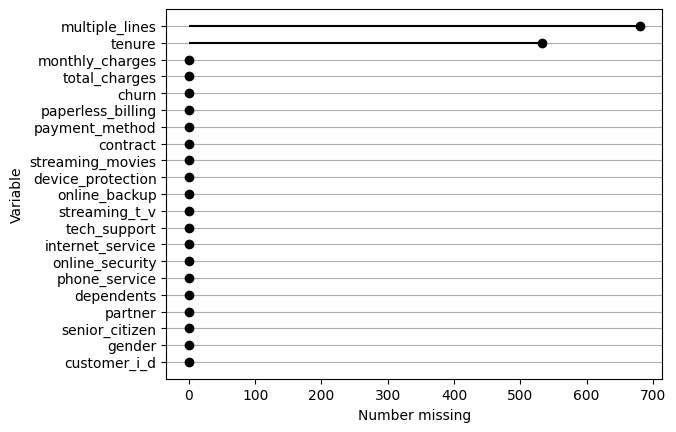

In [17]:
data_df.missing.missing_variable_plot()

<Axes: >

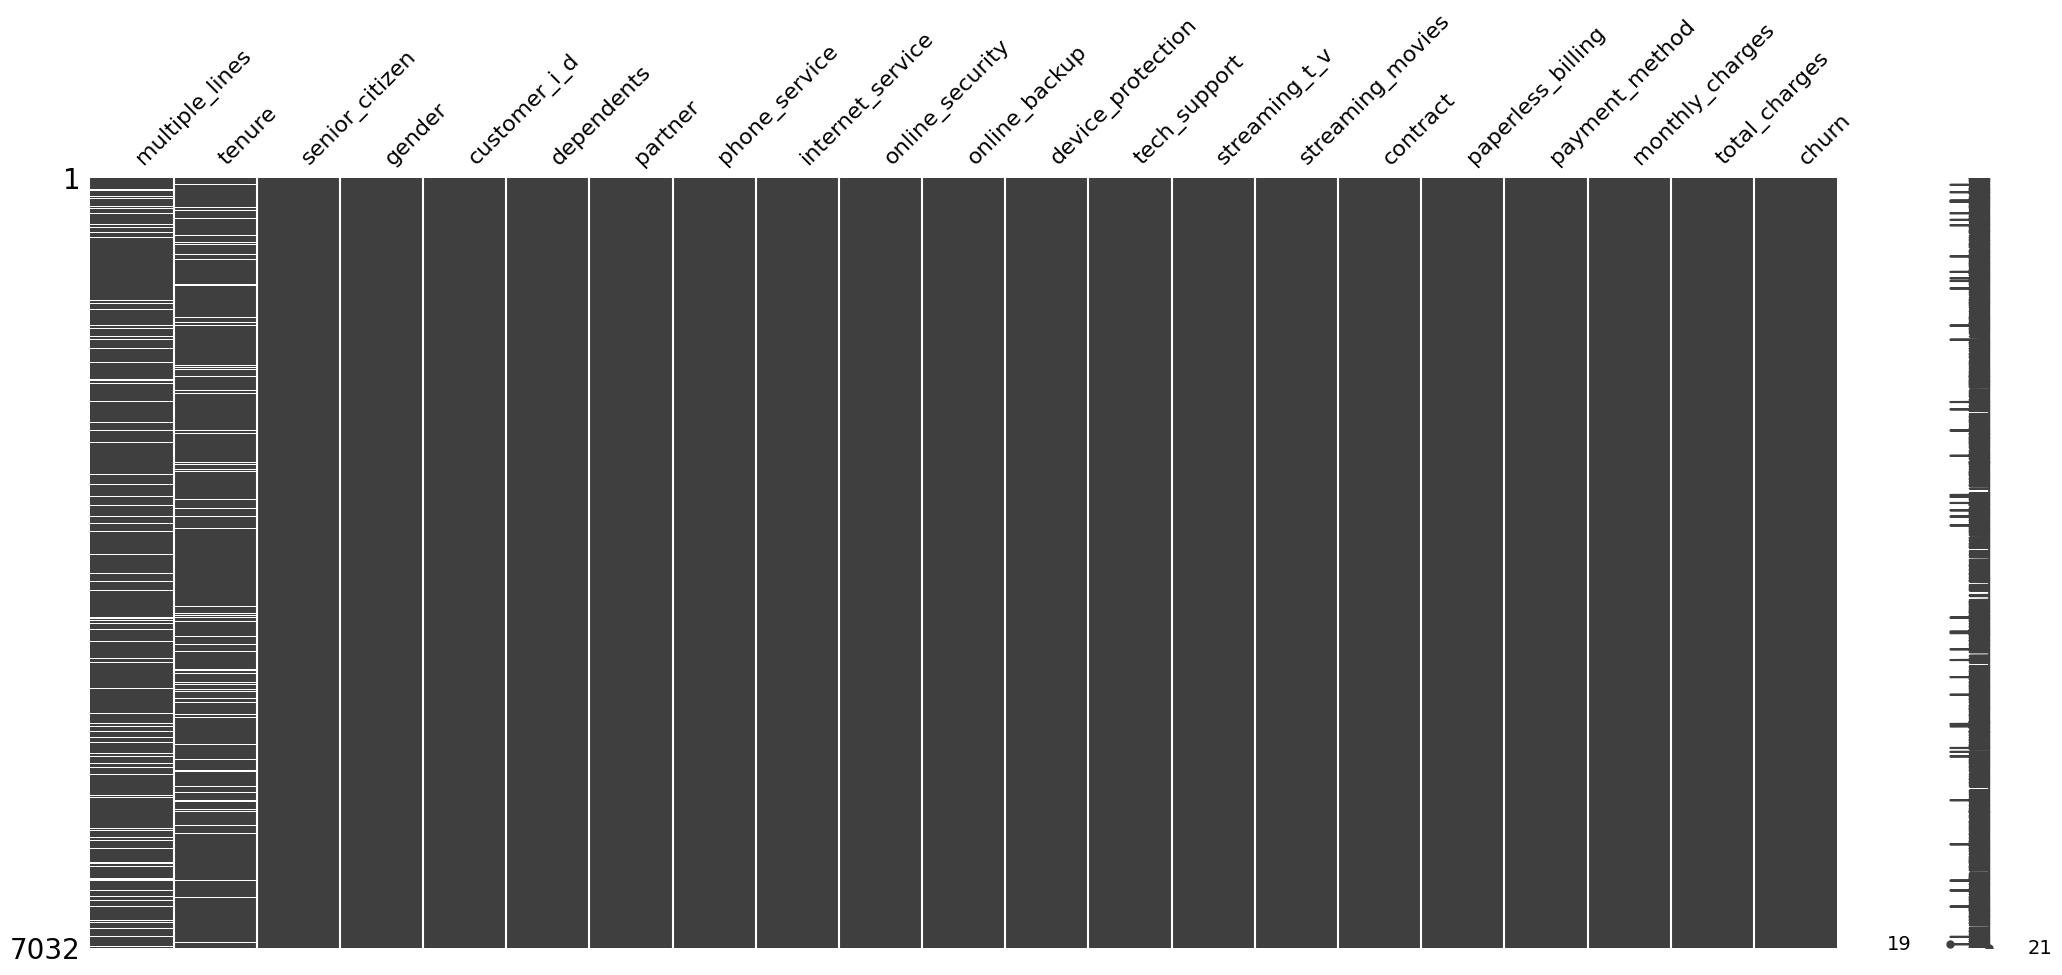

In [18]:
import missingno

data_df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

# EJERCICIOS A REALIZAR

## 1 - IMPUTAR TODOS LOS DATOS FALTANTES

In [19]:
data_df.dtypes

,0
customer_i_d,object
gender,object
senior_citizen,int64
partner,object
dependents,object
tenure,float64
phone_service,object
multiple_lines,object
internet_service,object
online_security,object


In [20]:
variable_nan = 'tenure'

In [21]:
df_tenure_mean = data_df.copy()
df_tenure_mean[variable_nan] = df_tenure_mean[variable_nan].fillna(round(df_tenure_mean[variable_nan].mean()))

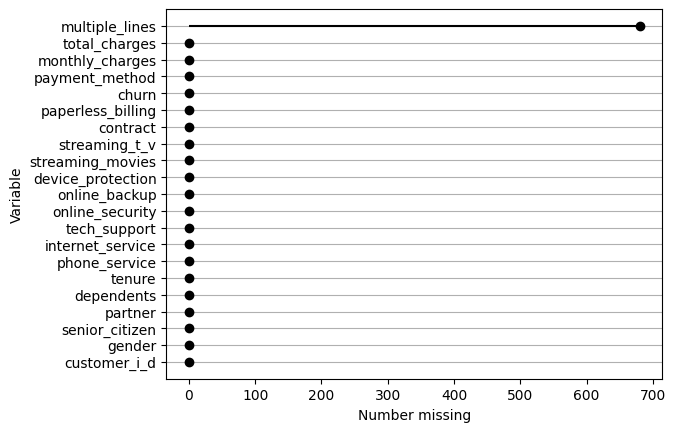

In [23]:
df_tenure_mean.missing.missing_variable_plot()

In [24]:
df_mutiples_lines = df_tenure_mean.copy()
df_mutiples_lines['multiple_lines'] = df_mutiples_lines['multiple_lines'].ffill()
df_mutiples_lines['multiple_lines'] = df_mutiples_lines['multiple_lines'].bfill()
df_mutiples_lines

,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,29.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11.0,No,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


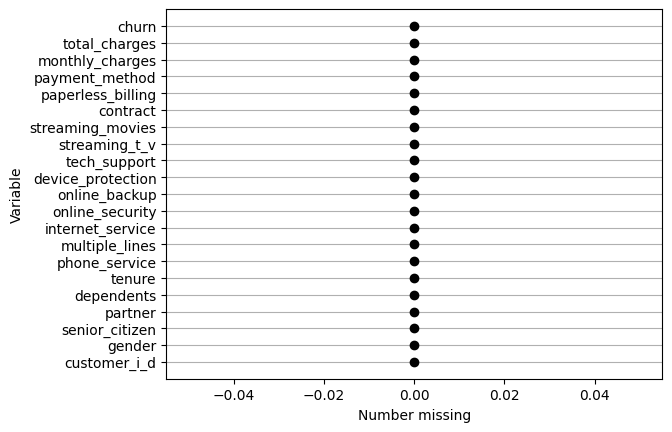

In [25]:
df_mutiples_lines.missing.missing_variable_plot()

In [26]:
df_clean = df_mutiples_lines.copy()
df_clean.to_csv('df_clean.csv', index=False)

## 2 - REALIZAR EDA( TIPOS DE DATOS, CONTEOS Y PROPORCIONES)

In [27]:
df_clean.dtypes.value_counts()

,count
object,17
float64,3
int64,1


## CONTEOS

In [29]:
df_clean.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,29.192833,64.798208,2283.300441
std,0.368844,21.824152,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,48.000000,89.862500,3794.737500
max,1.000000,70.000000,118.750000,8684.800000


In [30]:
df_clean.describe(include=object)

,customer_i_d,gender,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,2,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3758,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


<Axes: xlabel='internet_service'>

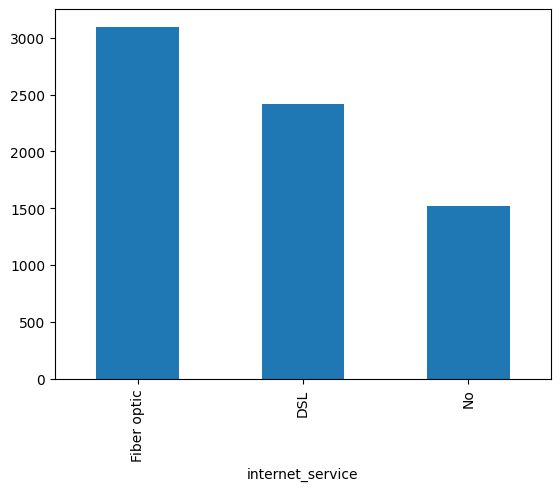

In [32]:
(
    df_clean
    .internet_service
    .value_counts()
    .plot(
        kind='bar'
    )
)

## PROPORCIONES

In [33]:
df_clean['variable'] = ''
df_clean

,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,variable
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,
3,7795-CFOCW,Male,0,No,No,45.0,No,No,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,
7028,2234-XADUH,Female,0,Yes,Yes,29.0,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,
7029,4801-JZAZL,Female,0,Yes,Yes,11.0,No,Yes,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,
7030,8361-LTMKD,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,


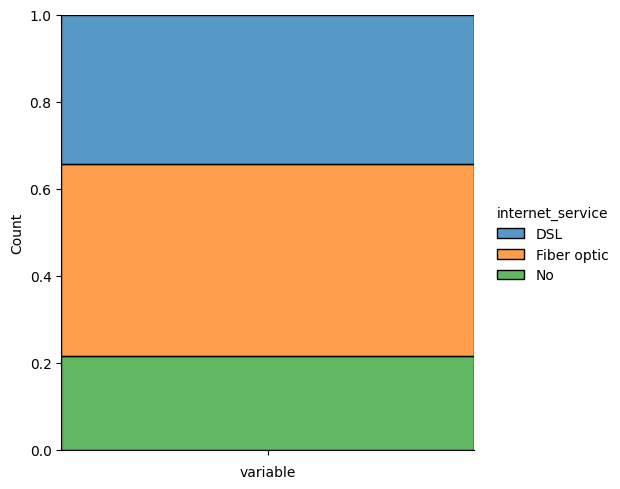

In [34]:
(
    df_clean
    .pipe(
        lambda df:(
            sns.displot(
                data=df,
                x='variable',
                hue='internet_service',
                multiple='fill'
            )
        )
    )
)

## 3 - ANALISIS UNIVARIADO DE VARIABLE CHURN

In [47]:
df_clean['churn_val'] = df_clean['churn'].map({'No': 0, 'Yes': 1})

In [48]:
variable = 'churn_val'
data = df_clean[variable]

In [49]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de churn_val
Media (μ): 0.27
Mediana: 0.00
Moda: 0.00


In [50]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de churn_val
Varianza (σ²): 0.20
Desviación estándar (σ): 0.44
Rango: 1.00
Rango intercuartílico (IQR): 1.00


In [51]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para churn_val
Límite inferior: -1.50
Límite superior: 2.50
Número de outliers detectados: 0


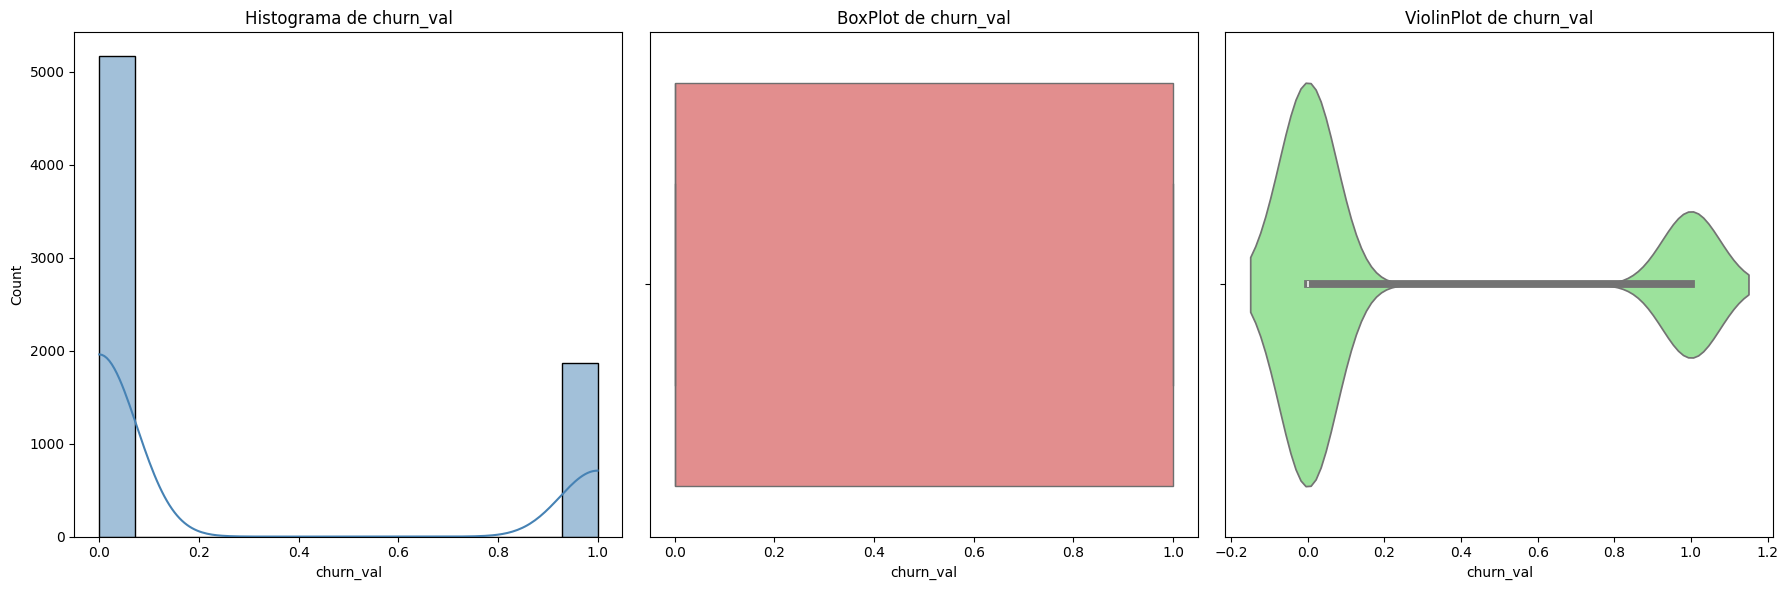

In [52]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

In [53]:
from scipy import stats
skew_val = stats.skew(data)
kurt_val = stats.kurtosis(data)

print("\n📉 Forma de la distribución")
print(f"Asimetría (skewness): {skew_val:.3f}")
print(f"Curtosis (kurtosis): {kurt_val:.3f}")


📉 Forma de la distribución
Asimetría (skewness): 1.060
Curtosis (kurtosis): -0.876


In [54]:
# Interpretación básica
if skew_val > 0.5:
    interpretacion = "Distribución sesgada a la derecha (cola larga a la derecha)"
elif skew_val < -0.5:
    interpretacion = "Distribución sesgada a la izquierda (cola larga a la izquierda)"
else:
    interpretacion = "Distribución aproximadamente simétrica"

print(f"🧩 Interpretación: {interpretacion}")

🧩 Interpretación: Distribución sesgada a la derecha (cola larga a la derecha)


In [55]:
# Interpretación básica de kurtosis
if kurt_val > 0 :
    interpretacion = "leptocúrtica"
elif kurt_val < 0:
    interpretacion = "platicúrtica"
else:
    interpretacion = "normal"

print(f"🧩 Kurtosis : {interpretacion}")

🧩 Kurtosis : platicúrtica


## 4 - CORRELACIONES ENTRE VARIABLES

<Axes: >

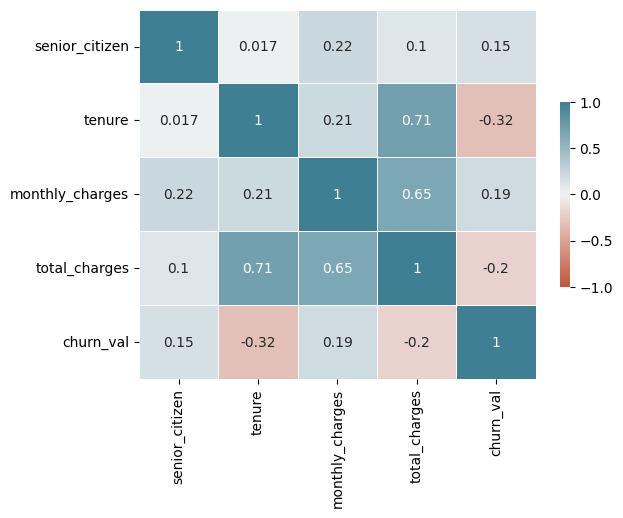

In [56]:
sns.heatmap(
    data=df_clean.corr(numeric_only=True),
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5}
)

<Axes: >

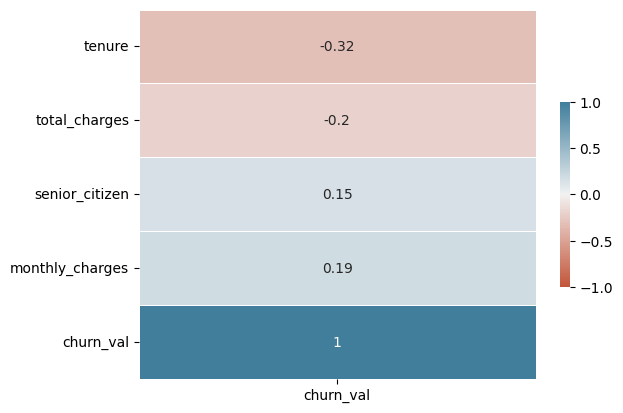

In [57]:
corr_matrix = df_clean.corr(numeric_only=True)
corr_body_mass = corr_matrix[['churn_val']].sort_values(by='churn_val',ascending=True)
sns.heatmap(
    data=corr_body_mass,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)